In [10]:
import numpy as np
from src.MaxVol import calculate_maxvol
import matplotlib.pyplot as plt
from src.latexfig import LatexFigure

In [28]:
# generate random vectors in 2D given a number of vectors and an x- and y-range
def generate_random_vectors(num_vectors, x_range, y_range):
    x_values = np.random.uniform(x_range[0], x_range[1], num_vectors)
    y_values = np.random.uniform(y_range[0], y_range[1], num_vectors)
    vectors = np.column_stack((x_values, y_values))
    return vectors

In [79]:
B = generate_random_vectors(100, (-10, 10), (-10, 10))
# Make an array of indicies for the vectors
B_indicies = np.array([i for i in range(len(B))])
# Calculate the maximum volume subset of vectors
A, select_indicies = calculate_maxvol(B, B_indicies, gamma_tol=1e-8)

In [80]:
B_out = generate_random_vectors(10, (-1, 1), (-15, 15))
B_out = np.concatenate((B_out, generate_random_vectors(10, (-15, 15), (-1, 1))), axis=0)

In [81]:
points = np.concatenate((B, B_out), axis=0)

In [84]:
points = points0

In [78]:
points0 = points

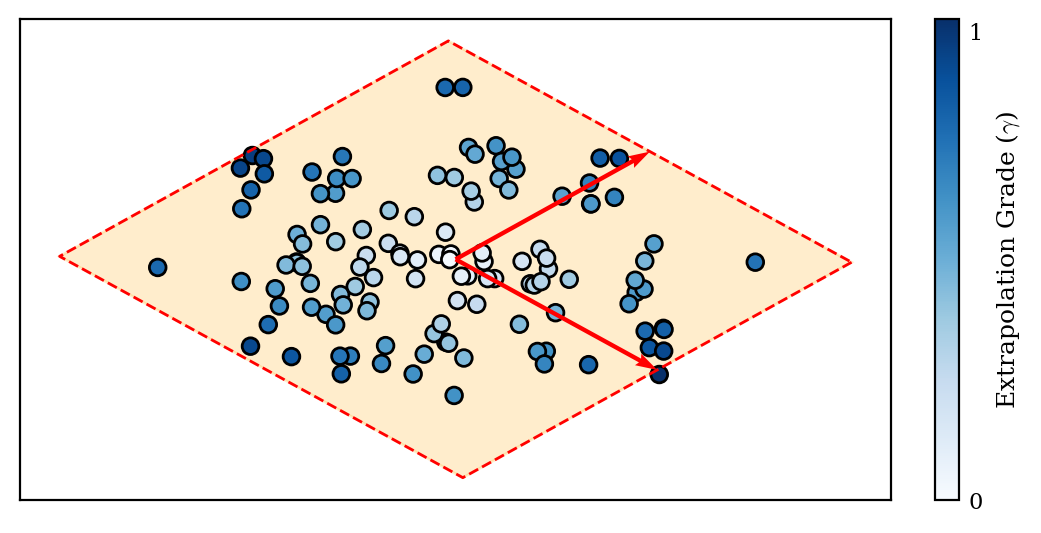

In [85]:
v1 = A[0]
v2 = A[1]
C = points @ np.linalg.inv(A)

importance = np.max(np.abs(C), axis=1)

lf = LatexFigure()
fig, axes = lf.create(AR=0.5)
ax = axes[0]

parallelogram = np.array([
    v1 + v2,
    v1 - v2,
    -v1 - v2,
    -v1 + v2,
    v1 + v2
])

ax.plot(parallelogram[:,0],
        parallelogram[:,1],
        color="red",
        ls="--",
        lw=1)

ax.fill(parallelogram[:,0],
        parallelogram[:,1],
        alpha=0.2,
        color="orange")


sc = ax.scatter(
    points[:,0],
    points[:,1],
    c=importance,
    cmap='Blues',
    edgecolor="black",
    vmin=0,
    vmax=np.max(importance)
)

ax.quiver(v1[0], v1[1], color="red", angles='xy', scale_units='xy', scale=1, width=0.005)
ax.quiver(v2[0], v2[1], color="red", angles='xy', scale_units='xy', scale=1, width=0.005)


cbar = plt.colorbar(
    sc,
    label='Extrapolation Grade ($\\gamma$)'
)
cbar.ax.set_yticks([0, 1])
cbar.ax.tick_params(length=0)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [77]:
fig.savefig("figures/gamma_hull.pdf", bbox_inches='tight')